🔄 Generating 5,000-row Titanic dataset...
✅ Dataset successfully built inline!

📊 Rendering visualization charts...


C:\Users\Admin\AppData\Local\Temp\ipykernel_4400\3679283849.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df, errorbar=None, palette="Set2")


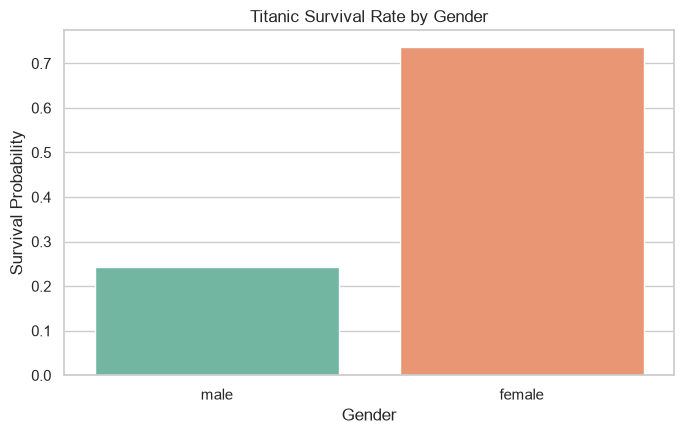

C:\Users\Admin\AppData\Local\Temp\ipykernel_4400\3679283849.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df, errorbar=None, palette="muted")


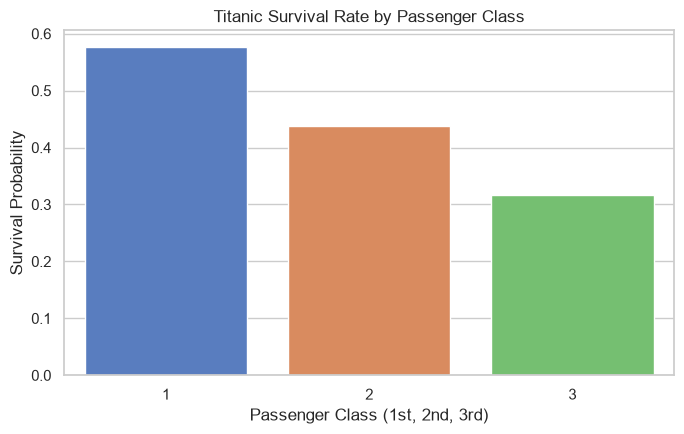

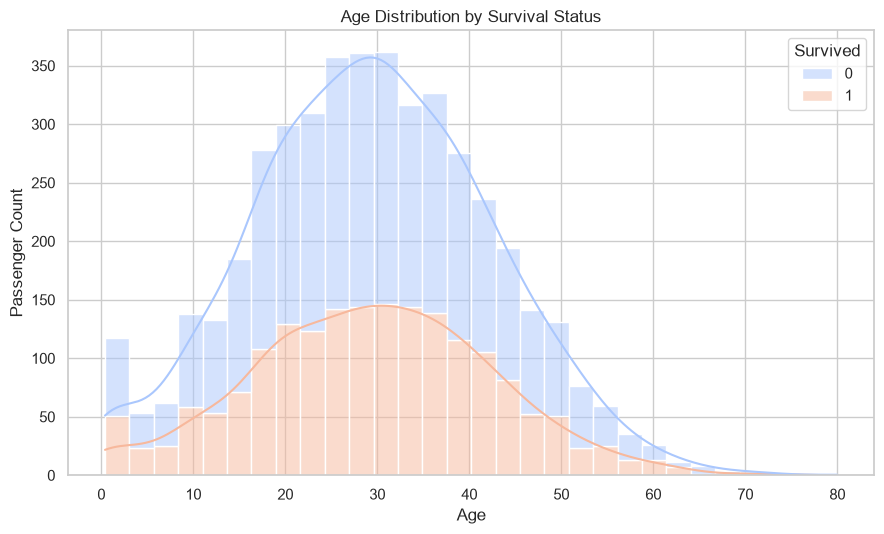

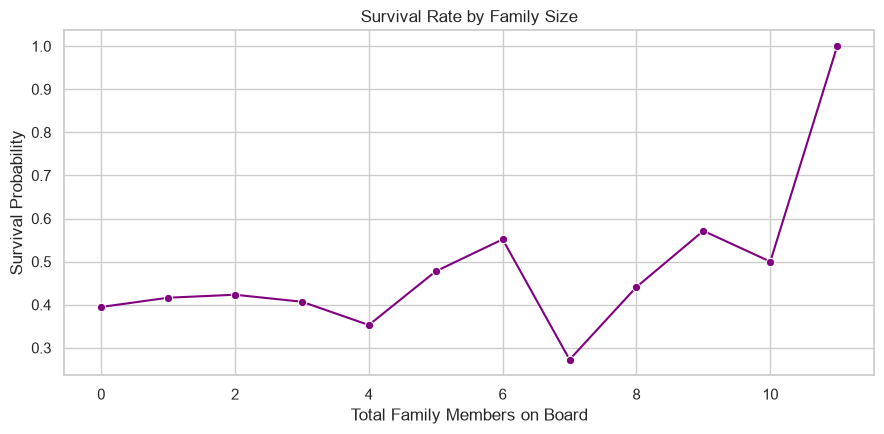

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# STEP 1: AUTOMATICALLY GENERATE DATASET
# ==========================================
print("🔄 Generating 5,000-row Titanic dataset...")
np.random.seed(42)
num_samples = 5000

passenger_ids = np.arange(1, num_samples + 1)
pclasses = np.random.choice([1, 2, 3], size=num_samples, p=[0.24, 0.21, 0.55])
sexes = np.random.choice(["male", "female"], size=num_samples, p=[0.65, 0.35])


def calculate_survival(sex, pclass):
    base_prob = 0.15
    if sex == "female":
        base_prob += 0.50
    if pclass == 1:
        base_prob += 0.25
    elif pclass == 2:
        base_prob += 0.10
    return np.random.choice([0, 1], p=[1 - np.clip(base_prob, 0.0, 1.0), np.clip(base_prob, 0.0, 1.0)])


survived = [calculate_survival(s, p) for s, p in zip(sexes, pclasses)]
ages = np.random.normal(loc=29, scale=13, size=num_samples)
ages = np.clip(ages, 0.42, 80)
ages[np.random.choice(num_samples, size=int(num_samples * 0.1), replace=False)] = np.nan
sibsp = np.random.choice([0, 1, 2, 3, 4, 5, 8], size=num_samples, p=[0.68, 0.23, 0.04, 0.02, 0.01, 0.01, 0.01])
parch = np.random.choice([0, 1, 2, 3, 4, 5, 6], size=num_samples, p=[0.76, 0.13, 0.09, 0.01, 0.005, 0.003, 0.002])

# Build DataFrame
df = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": survived,
    "Pclass": pclasses,
    "Sex": sexes,
    "Age": np.round(ages, 1),
    "SibSp": sibsp,
    "Parch": parch
})

# Add derived metric for analysis
df["FamilySize"] = df["SibSp"] + df["Parch"]
print("✅ Dataset successfully built inline!\n")

# ==========================================
# STEP 2: PLOT & DISPLAY THE CHARTS
# ==========================================
print("📊 Rendering visualization charts...")
sns.set_theme(style="whitegrid")

# --- CHART 1: Survival Rate by Gender ---
plt.figure(figsize=(7, 4.5))
sns.barplot(x="Sex", y="Survived", data=df, errorbar=None, palette="Set2")
plt.title("Titanic Survival Rate by Gender")
plt.ylabel("Survival Probability")
plt.xlabel("Gender")
plt.tight_layout()
plt.show()  # 💡 CLOSE THIS WINDOW FOR THE NEXT CHART TO APPEAR

# --- CHART 2: Survival Rate by Passenger Class ---
plt.figure(figsize=(7, 4.5))
sns.barplot(x="Pclass", y="Survived", data=df, errorbar=None, palette="muted")
plt.title("Titanic Survival Rate by Passenger Class")
plt.ylabel("Survival Probability")
plt.xlabel("Passenger Class (1st, 2nd, 3rd)")
plt.tight_layout()
plt.show()  # 💡 CLOSE THIS WINDOW FOR THE NEXT CHART TO APPEAR

# --- CHART 3: Age Distribution by Survival Status ---
plt.figure(figsize=(9, 5.5))
sns.histplot(data=df, x="Age", hue="Survived", multiple="stack", kde=True, palette="coolwarm", bins=30)
plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.tight_layout()
plt.show()  # 💡 CLOSE THIS WINDOW FOR THE NEXT CHART TO APPEAR

# --- CHART 4: Survival Rate by Family Size ---
plt.figure(figsize=(9, 4.5))
sns.lineplot(x="FamilySize", y="Survived", data=df, marker="o", color="purple", errorbar=None)
plt.title("Survival Rate by Family Size")
plt.ylabel("Survival Probability")
plt.xlabel("Total Family Members on Board")
plt.tight_layout()
plt.show()